In [ ]:

#Assignment No 6: Assignment based on Time Series Forecasting,

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [2]:
#import libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import confusion_matrix

In [3]:
# Load Dataset
df = pd.read_csv('RELIANCE.csv')
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [4]:
# Select Needed Columns
df = df[['Date','Close']]
df.head()

,Date,Close
0,2000-01-03,251.70
1,2000-01-04,271.85
2,2000-01-05,282.50
3,2000-01-06,294.35
4,2000-01-07,314.55


In [5]:
# Convert Date to Time-Series Index
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [6]:
# Resample Daily to Monthly
monthly = df['Close'].resample('M').mean().to_frame()
monthly.head()

,Close
Date,
2000-01-31,308.555000
2000-02-29,342.054762
2000-03-31,253.926190
2000-04-30,330.416667
2000-05-31,323.534091


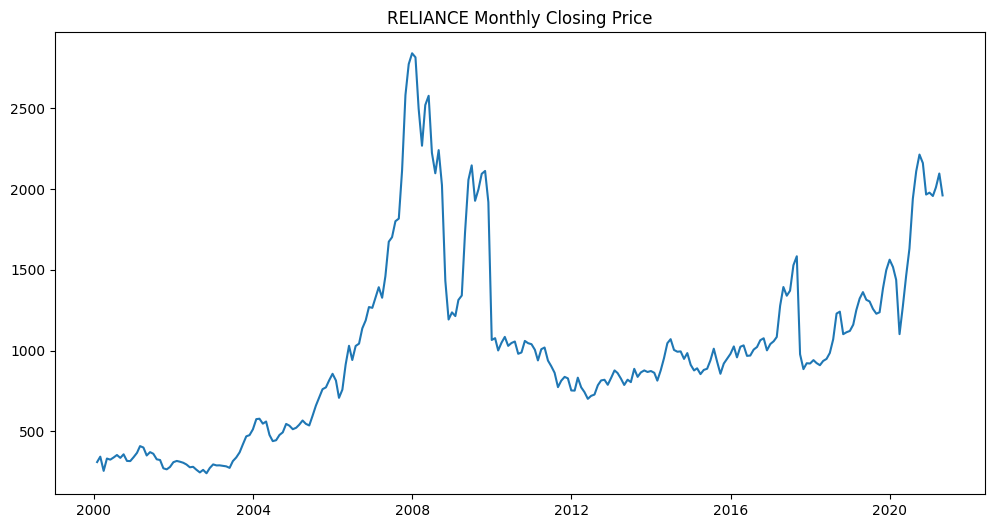

In [7]:
# Plot Stock Trend
plt.figure(figsize=(12,6))
plt.plot(monthly['Close'])
plt.title('RELIANCE Monthly Closing Price')
plt.show()

<Figure size 1200x600 with 0 Axes>

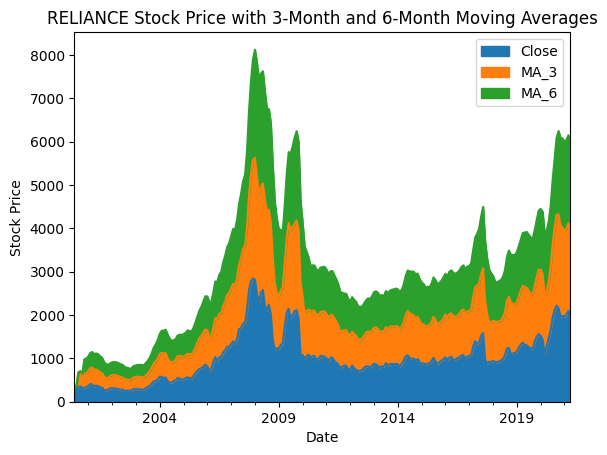

In [24]:
# Moving Averages
monthly['MA_3']=monthly['Close'].rolling(3).mean()
monthly['MA_6']=monthly['Close'].rolling(6).mean()

plt.figure(figsize=(12,6))
monthly[['Close','MA_3','MA_6']].plot.area()
plt.title('RELIANCE Stock Price with 3-Month and 6-Month Moving Averages')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.show()

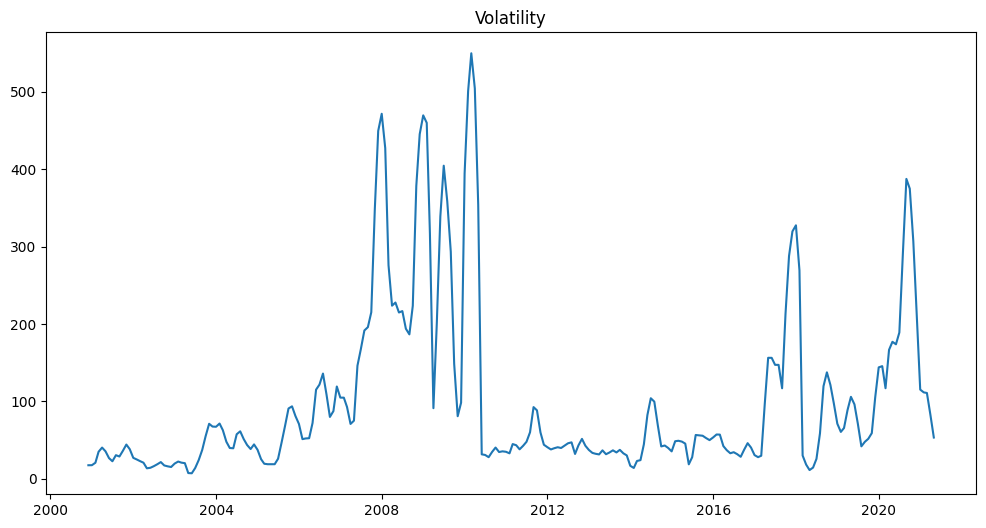

In [26]:
# Volatility
monthly['Volatility']=monthly['Close'].rolling(6).std()

plt.figure(figsize=(12,6))
plt.plot(monthly['Volatility'])
plt.title('Volatility')
plt.show()

In [10]:
# np.diff() Transformation
monthly['Price_Change']=np.diff(monthly['Close'],prepend=monthly['Close'].iloc[0])
monthly.head()

,Close,MA_3,MA_6,Volatility,Price_Change
Date,,,,,
2000-01-31,308.555000,NaN,NaN,NaN,0.000000
2000-02-29,342.054762,NaN,NaN,NaN,33.499762
2000-03-31,253.926190,301.511984,NaN,NaN,-88.128571
2000-04-30,330.416667,308.799206,NaN,NaN,76.490476
2000-05-31,323.534091,302.625649,NaN,NaN,-6.882576


In [11]:
# ADF Stationarity Test
result=adfuller(monthly['Close'].dropna())
print(result[0])
print(result[1])

-1.9250307012096781
0.32037903237977855


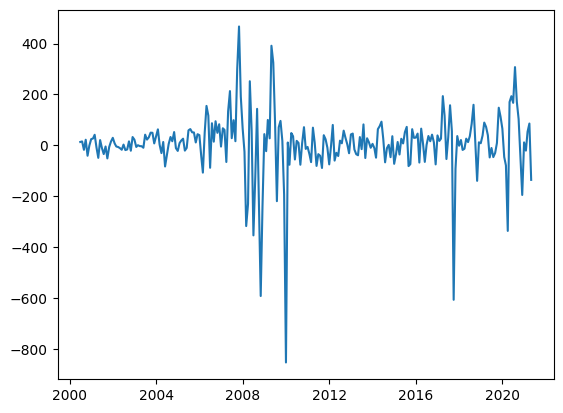

In [12]:
# Differencing
monthly['Diff']=monthly['Close'].diff()
monthly.dropna(inplace=True)

plt.plot(monthly['Diff'])
plt.show()

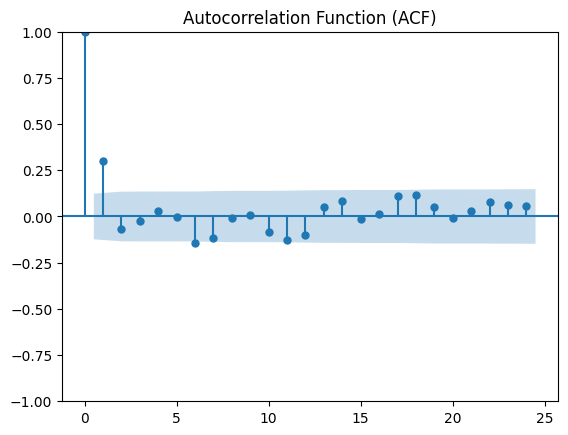

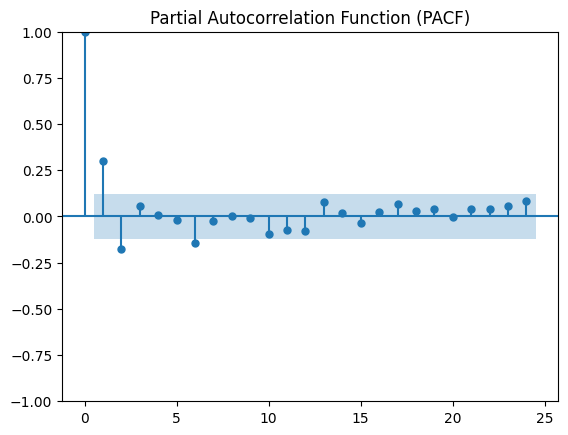

In [31]:
# ACF and PACF
plot_acf(monthly['Diff'])
plt.title('Autocorrelation Function (ACF)')
plt.show()

plot_pacf(monthly['Diff'])
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [14]:
# Train Test Split
train=monthly.iloc[:int(len(monthly)*0.8)]
test=monthly.iloc[int(len(monthly)*0.8):]

In [15]:
# Train ARIMA Model
model=ARIMA(train['Close'],order=(2,1,2))
fit=model.fit()
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  200
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1215.570
Date:                Sun, 19 Apr 2026   AIC                           2441.140
Time:                        19:14:59   BIC                           2457.607
Sample:                    06-30-2000   HQIC                          2447.805
                         - 01-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0791      0.671     -0.118      0.906      -1.395       1.236
ar.L2         -0.1812      0.127     -1.429      0.153      -0.430       0.067
ma.L1          0.4632      0.673      0.688      0.4

In [16]:
# Predictions
pred=fit.forecast(steps=len(test))

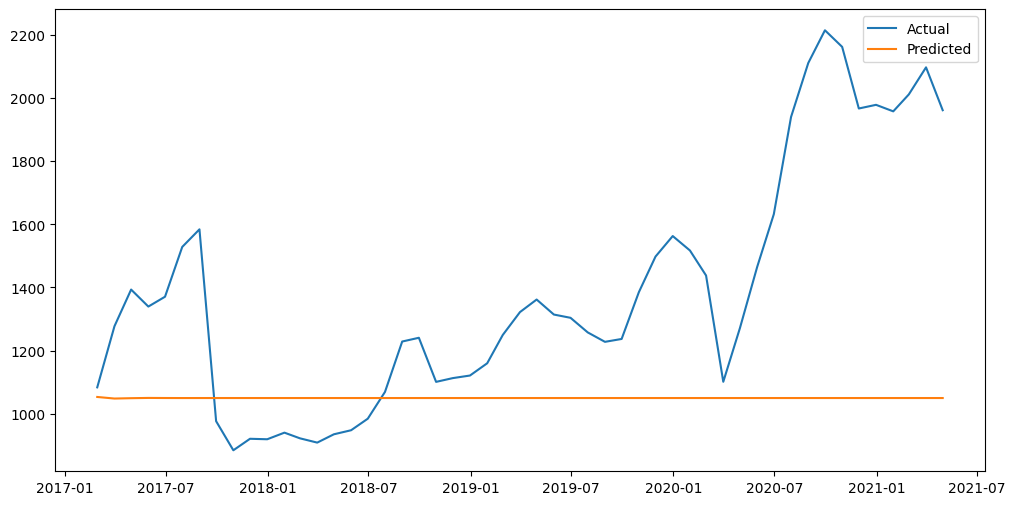

In [30]:
# Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test.index,test['Close'])
plt.plot(test.index,pred)
plt.legend(['Actual','Predicted'])
plt.show()

In [18]:
# Evaluation Metrics
mae=mean_absolute_error(test['Close'],pred)
mse=mean_squared_error(test['Close'],pred)
rmse=np.sqrt(mse)
mape=mean_absolute_percentage_error(test['Close'],pred)

print('MAE=',mae)
print('MSE=',mse)
print('RMSE=',rmse)
print('MAPE=',mape)


# Accuracy
accuracy=100-(mape*100)
print(accuracy)

MAE= 377.7346340793741
MSE= 254046.16376128563
RMSE= 504.0299234780467
MAPE= 0.23502337887949937
76.49766211205007


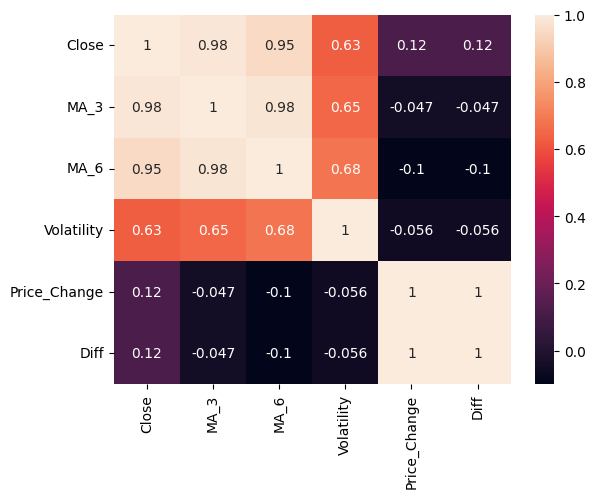

In [19]:
# Heatmap
sns.heatmap(monthly.corr(),annot=True)
plt.show()

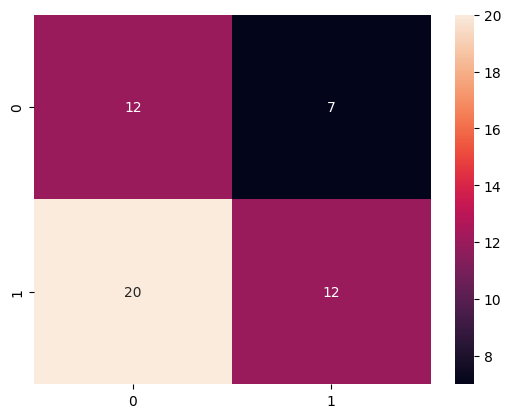

In [20]:
# Confusion Matrix (Trend)
actual=np.where(test['Close'].diff().fillna(0)>0,1,0)
pred_dir=np.where(pd.Series(pred).diff().fillna(0)>0,1,0)

cm=confusion_matrix(actual,pred_dir)
sns.heatmap(cm,annot=True)
plt.show()


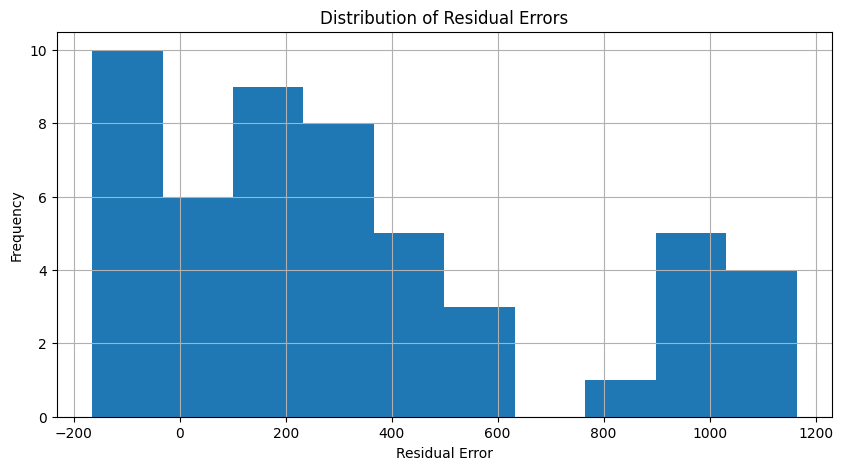

In [27]:
# Residual Plot
residuals=test['Close']-pred

plt.figure(figsize=(10,5))
residuals.hist()
plt.title('Distribution of Residual Errors')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.show()

In [22]:
# Future Forecast (12 Months)
final_model=ARIMA(monthly['Close'],order=(2,1,2))
final_fit=final_model.fit()

future=final_fit.forecast(steps=12)
print(future)

2021-05-31    1910.576692
2021-06-30    1912.651269
2021-07-31    1913.937106
2021-08-31    1912.582026
2021-09-30    1913.787029
2021-10-31    1912.729078
2021-11-30    1913.656939
2021-12-31    1912.843243
2022-01-31    1913.556816
2022-02-28    1912.931047
2022-03-31    1913.479816
2022-04-30    1912.998572
Freq: ME, Name: predicted_mean, dtype: float64


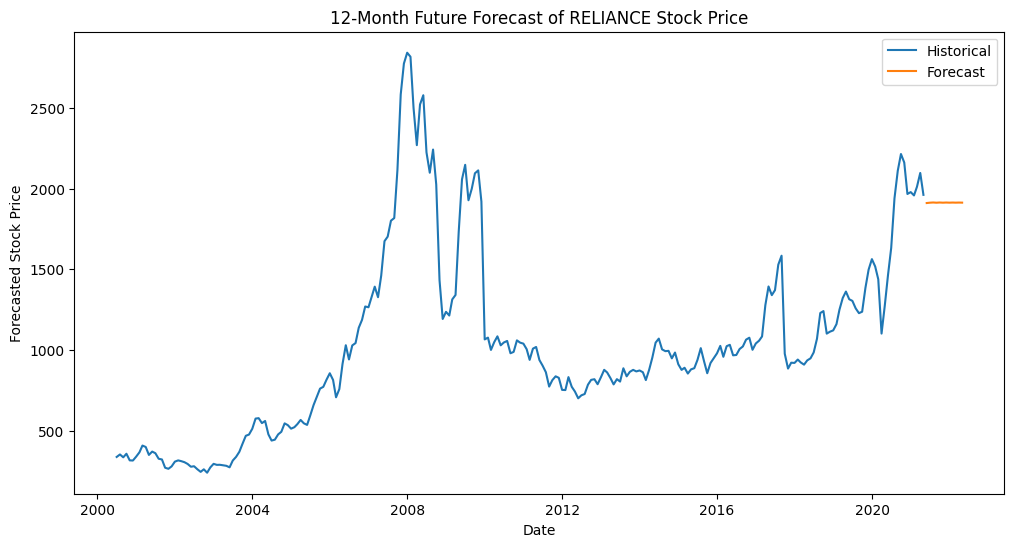

In [28]:
# Forecast Graph
future_dates=pd.date_range(start=monthly.index[-1],periods=13,freq='M')[1:]
future_series=pd.Series(future,index=future_dates)

plt.figure(figsize=(12,6))
plt.plot(monthly['Close'])
plt.plot(future_series)
plt.legend(['Historical','Forecast'])
plt.title('12-Month Future Forecast of RELIANCE Stock Price')
plt.xlabel('Date')
plt.ylabel('Forecasted Stock Price')
plt.show()